# Advanced Regression — Predicting Fat Mass Index (FMI)
### Dataset: Child Mind Institute (CMI) — Module 1

**Task:** Multiple regression — predict `BIA-BIA_FMI` (Fat Mass Index, kg/m²)  
**Models:** Random Forest · XGBoost (with early stopping) · LightGBM  
**Improvements over baseline:** feature engineering · LightGBM · XGBoost early stopping · permutation importance  
**Metrics:** R², Adjusted R², RMSE, MAE, MAPE

## 0. Installs

In [1]:
!pip install xgboost lightgbm -q

## 1. Imports

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import defaultdict

## 2. Load Data

In [3]:
df = pd.read_csv('cmi_module1_clean-1.csv')

print('Shape:', df.shape)
df.head()

Shape: (8417, 32)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,FGC_Grip_Avg,PAQ_Total,SDS_measured,BIA_measured,FGC_Muscular_Endurance,Social_Digital_Displacement,Lifestyle_Risk_Score,Metabolic_Alarms_Count,ScreenTime_Age_Ratio,ScreenTime_Category
0,5,0,51.0,16.877316,55.00,50.8,26.00,68.0,81.0,114.0,...,20.05,2.010,0,1,0.0,0.491803,1.182226,0,0.500000,2
1,9,0,65.0,14.035590,57.08,46.0,22.00,75.0,70.0,122.0,...,20.05,2.010,1,1,4.0,0.000000,0.972226,1,0.000000,0
2,10,1,71.0,16.648696,56.50,75.6,27.02,65.0,94.0,117.0,...,12.45,2.170,1,1,13.5,0.246914,1.055457,0,0.181818,1
3,9,0,71.0,18.292347,56.00,81.6,26.00,60.0,97.0,117.0,...,20.05,2.451,1,1,11.5,0.000000,0.739771,0,0.000000,0
4,18,1,65.0,17.937682,55.00,77.0,26.00,68.0,81.0,114.0,...,20.05,1.040,0,1,6.0,0.133333,1.140196,1,0.052632,1


In [4]:
print(df.dtypes)

Basic_Demos-Age                             int64
Basic_Demos-Sex                             int64
CGAS-CGAS_Score                           float64
Physical-BMI                              float64
Physical-Height                           float64
Physical-Weight                           float64
Physical-Waist_Circumference              float64
Physical-Diastolic_BP                     float64
Physical-HeartRate                        float64
Physical-Systolic_BP                      float64
Fitness_Endurance-Max_Stage               float64
BIA-BIA_Activity_Level_num                float64
BIA-BIA_FFM                               float64
BIA-BIA_FFMI                              float64
BIA-BIA_FMI                               float64
BIA-BIA_Fat                               float64
BIA-BIA_Frame_num                         float64
BIA-BIA_SMM                               float64
SDS-SDS_Total_T                           float64
PreInt_EduHx-computerinternet_hoursday    float64


In [5]:
df.describe()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,FGC_Grip_Avg,PAQ_Total,SDS_measured,BIA_measured,FGC_Muscular_Endurance,Social_Digital_Displacement,Lifestyle_Risk_Score,Metabolic_Alarms_Count,ScreenTime_Age_Ratio,ScreenTime_Category
count,8417.000000,8417.000000,8417.000000,8417.000000,8417.000000,8417.000000,8417.000000,8417.000000,8417.000000,8417.000000,...,8417.000000,8417.000000,8417.000000,8417.0,8417.000000,8417.000000,8417.000000,8417.000000,8417.000000,8417.000000
mean,10.223001,0.402519,65.374064,19.386651,58.376050,84.238711,26.876208,68.837492,81.816813,115.528361,...,20.201253,2.205136,0.578947,1.0,6.957764,0.132339,0.985580,0.588452,0.085630,0.656528
std,3.566826,0.490434,8.592271,4.357661,5.762184,36.815757,3.396007,10.324815,10.733818,13.021678,...,5.839485,0.535836,0.493757,0.0,5.699974,0.138721,0.153085,0.828611,0.093182,0.632420
min,5.000000,0.000000,25.000000,10.281688,50.000000,12.300000,18.000000,40.000000,33.000000,70.000000,...,0.000000,0.580000,0.000000,1.0,0.000000,0.000000,0.592712,0.000000,0.000000,0.000000
25%,7.000000,0.000000,61.500000,16.710360,55.000000,57.600000,25.100000,63.500000,76.500000,109.000000,...,18.025000,2.000000,0.000000,1.0,3.500000,0.000000,0.883333,0.000000,0.000000,0.000000
50%,10.000000,0.000000,65.000000,17.937682,56.010000,77.000000,26.000000,68.000000,81.000000,114.000000,...,20.050000,2.010000,1.000000,1.0,6.000000,0.132450,0.982226,0.000000,0.076923,1.000000
75%,12.000000,1.000000,70.000000,20.981332,62.170000,103.500000,28.100000,71.500000,86.500000,119.500000,...,21.200000,2.300000,1.000000,1.0,8.500000,0.264901,1.082226,1.000000,0.142857,1.000000
max,22.000000,1.000000,97.500000,59.132048,78.500000,298.800000,50.000000,146.000000,138.000000,203.000000,...,93.600000,5.000000,1.000000,1.0,56.000000,0.731707,1.771698,5.000000,0.500000,2.000000


## 3. Exploratory Data Analysis

### 3.1 Missing Values

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing)
print()
print(f'Total rows: {len(df)}')

Columns with missing values:
Series([], dtype: int64)

Total rows: 8417


### 3.2 Target Variable — `BIA-BIA_FMI`

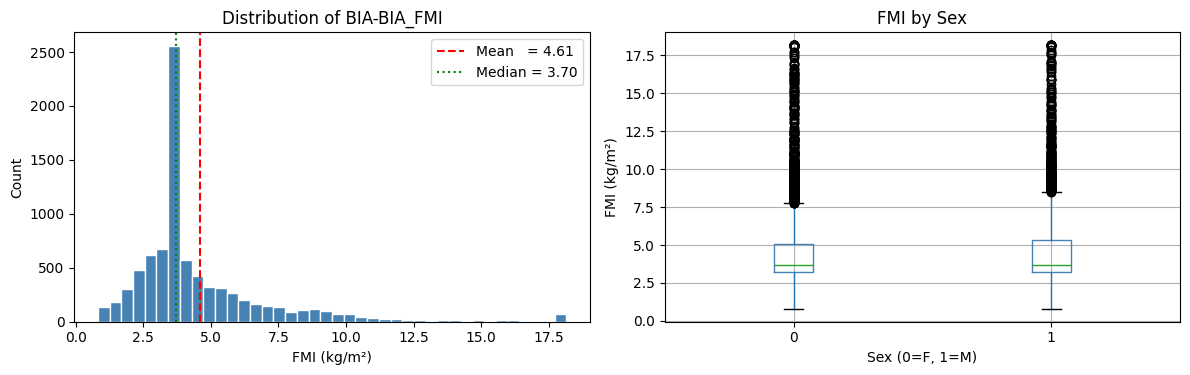

Skewness : 2.325
Kurtosis : 6.926
count    8417.000
mean        4.612
std         2.741
min         0.812
25%         3.228
50%         3.699
75%         5.179
max        18.153
Name: BIA-BIA_FMI, dtype: float64


In [7]:
TARGET = 'BIA-BIA_FMI'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df[TARGET].mean(),   color='red',   linestyle='--', label=f"Mean   = {df[TARGET].mean():.2f}")
axes[0].axvline(df[TARGET].median(), color='green', linestyle=':',  label=f"Median = {df[TARGET].median():.2f}")
axes[0].set_xlabel('FMI (kg/m²)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of BIA-BIA_FMI')
axes[0].legend()

if 'Basic_Demos-Sex' in df.columns:
    df.boxplot(column=TARGET, by='Basic_Demos-Sex', ax=axes[1],
               boxprops=dict(color='steelblue'))
    axes[1].set_xlabel('Sex (0=F, 1=M)')
    axes[1].set_ylabel('FMI (kg/m²)')
    axes[1].set_title('FMI by Sex')
    plt.suptitle('')
else:
    axes[1].hist(df[TARGET].dropna(), bins=40, color='darkorange', edgecolor='white')
    axes[1].set_title('FMI distribution (alt)')

plt.tight_layout()
plt.show()

print('Skewness : %.3f' % df[TARGET].skew())
print('Kurtosis : %.3f' % df[TARGET].kurtosis())
print(df[TARGET].describe().round(3))

### 3.3 Leakage Detection — Correlation with FMI

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df[numeric_cols].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

print('Absolute Pearson correlation with BIA-BIA_FMI:')
print(corr_with_target.round(3).to_string())

leakage_flag = corr_with_target[corr_with_target > 0.97]
if len(leakage_flag):
    print(f'\n⚠  Near-perfect correlates (|r| > 0.97) → DATA LEAKAGE:')
    print(leakage_flag)
else:
    print('\nNo near-perfect correlates detected above 0.97')

Absolute Pearson correlation with BIA-BIA_FMI:
BIA-BIA_Fat                               0.577
Physical-BMI                              0.544
BIA-BIA_FFMI                              0.518
Physical-Weight                           0.501
BIA-BIA_FFM                               0.486
BIA-BIA_SMM                               0.472
Metabolic_Alarms_Count                    0.464
Physical-Waist_Circumference              0.428
Physical-Height                           0.401
BIA-BIA_Frame_num                         0.374
Basic_Demos-Age                           0.358
Physical-Systolic_BP                      0.228
FGC_Grip_Avg                              0.216
PreInt_EduHx-computerinternet_hoursday    0.206
Social_Digital_Displacement               0.205
ScreenTime_Category                       0.200
Lifestyle_Risk_Score                      0.165
Physical-Diastolic_BP                     0.124
sii                                       0.112
FGC_Muscular_Endurance                   

### 3.4 Correlation Heatmap (top features)

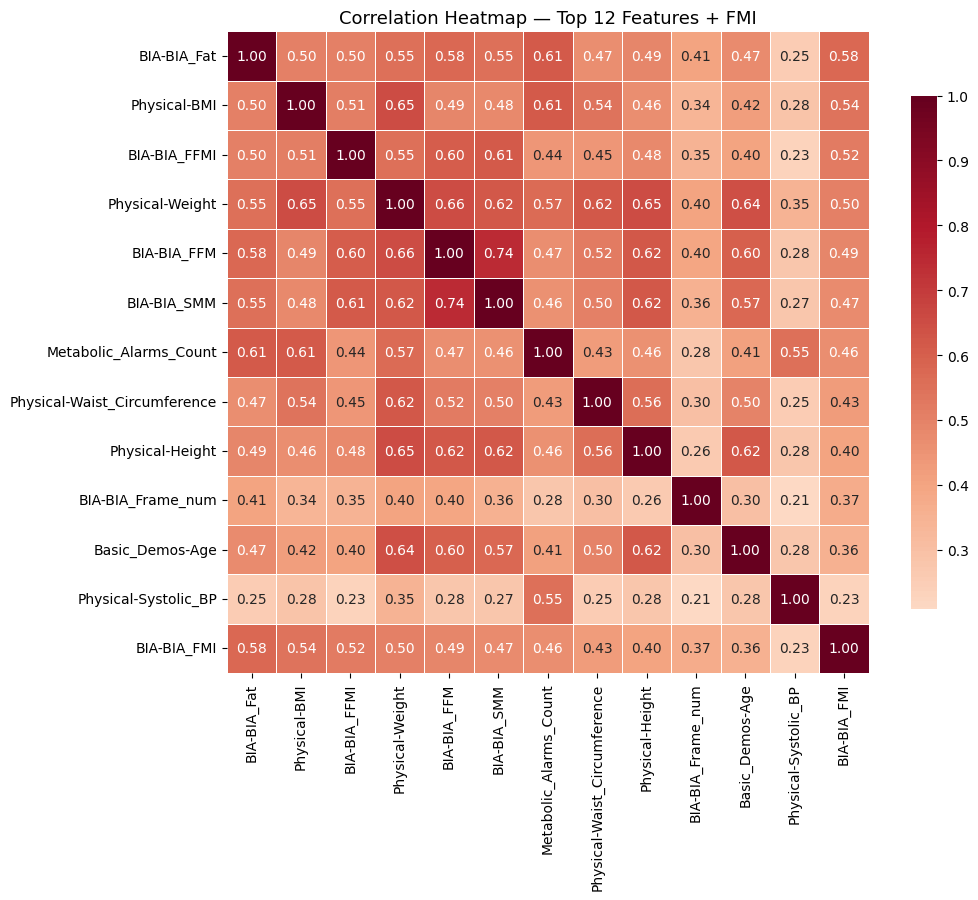

In [9]:
top_cols = corr_with_target.head(12).index.tolist() + [TARGET]

plt.figure(figsize=(11, 9))
sns.heatmap(
    df[top_cols].corr(),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Top 12 Features + FMI', fontsize=13)
plt.tight_layout()
plt.show()

### 3.5 Outlier Check (IQR)

In [10]:
print('Outlier counts per column (IQR × 1.5):')
for col in df.select_dtypes(include=[np.number]).columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        print(f'  {col:<35}: {n_out} ({100*n_out/len(df):.1f}%)')

Outlier counts per column (IQR × 1.5):
  Basic_Demos-Age                    : 82 (1.0%)
  CGAS-CGAS_Score                    : 574 (6.8%)
  Physical-BMI                       : 459 (5.5%)
  Physical-Height                    : 116 (1.4%)
  Physical-Weight                    : 235 (2.8%)
  Physical-Waist_Circumference       : 525 (6.2%)
  Physical-Diastolic_BP              : 752 (8.9%)
  Physical-HeartRate                 : 603 (7.2%)
  Physical-Systolic_BP               : 785 (9.3%)
  Fitness_Endurance-Max_Stage        : 2327 (27.6%)
  BIA-BIA_Activity_Level_num         : 116 (1.4%)
  BIA-BIA_FFM                        : 545 (6.5%)
  BIA-BIA_FFMI                       : 1159 (13.8%)
  BIA-BIA_FMI                        : 835 (9.9%)
  BIA-BIA_Fat                        : 706 (8.4%)
  BIA-BIA_SMM                        : 568 (6.7%)
  SDS-SDS_Total_T                    : 3325 (39.5%)
  sii                                : 86 (1.0%)
  FGC_Flexibility_Avg                : 412 (4.9%)
  FGC_G

### 3.6 Feature Distributions

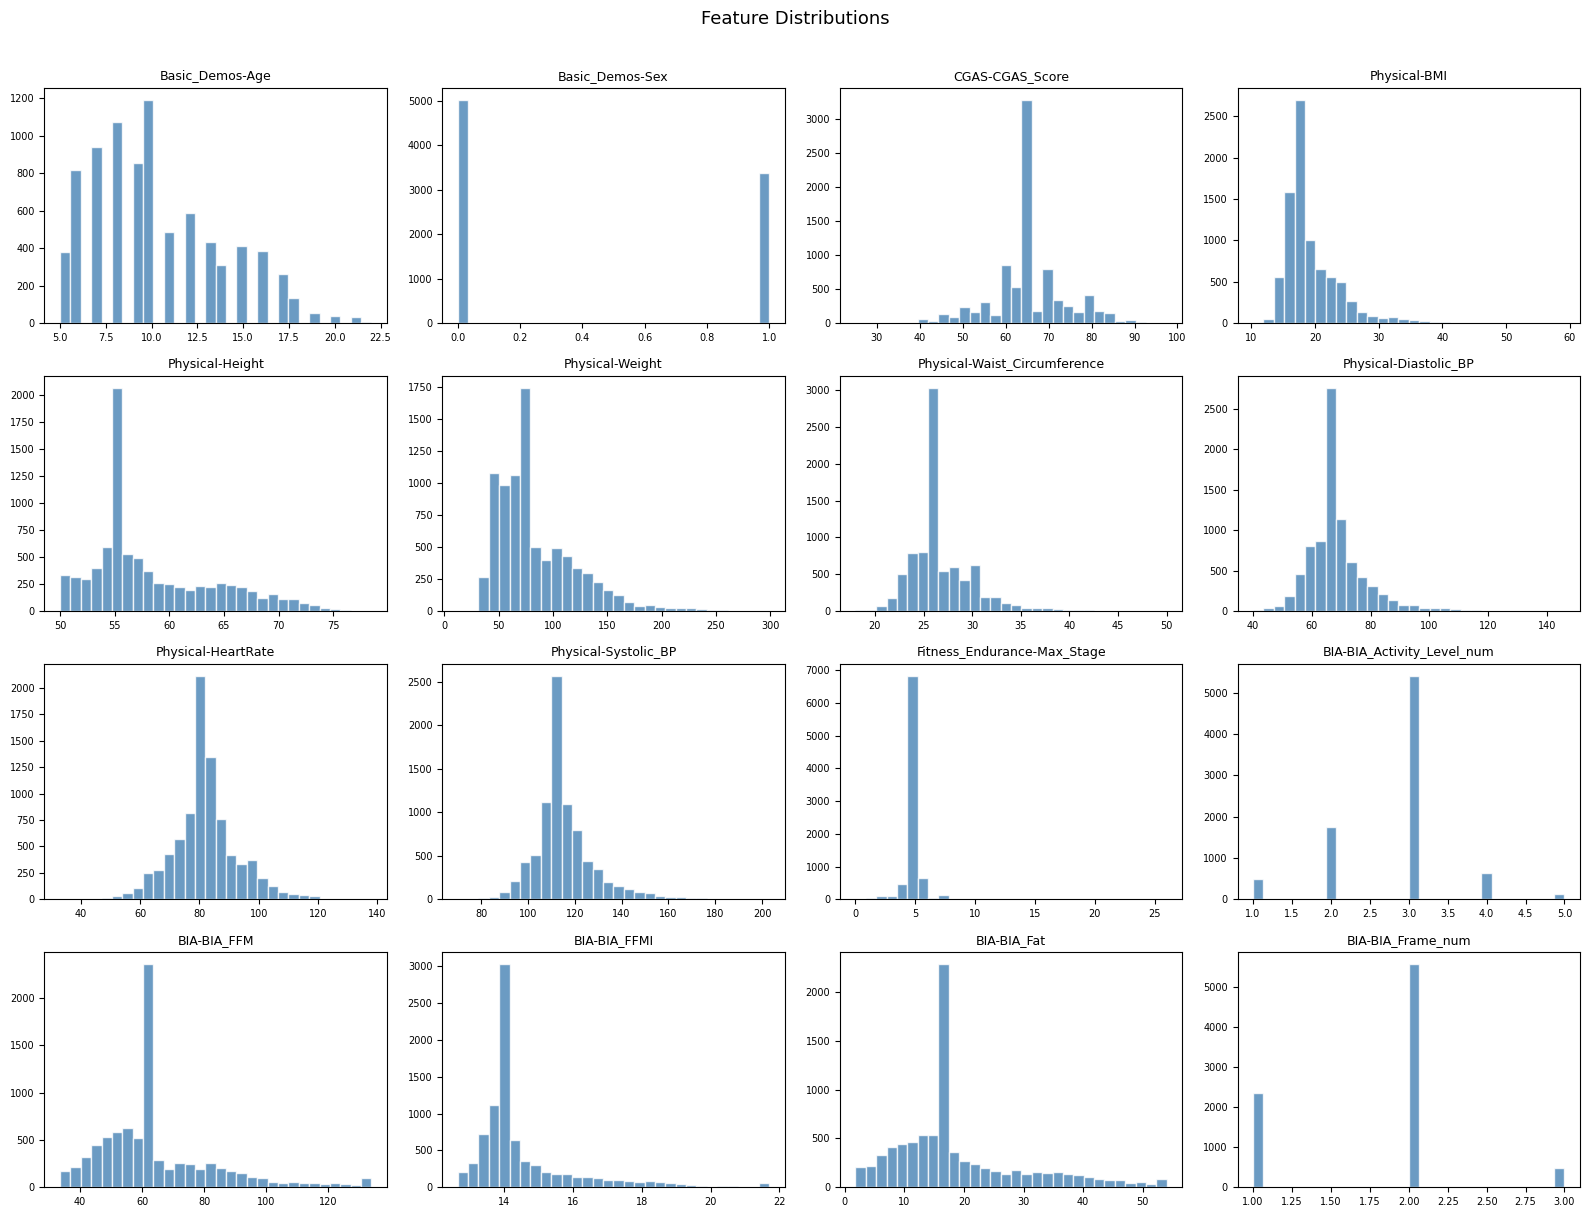

In [11]:
plot_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c != TARGET][:16]

ncols = 4
nrows = int(np.ceil(len(plot_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Preprocessing, Feature Engineering & Feature Selection

**Leakage columns removed:**
- `BIA-BIA_FFMI` — Fat-Free Mass Index = BMI − FMI → algebraically contains FMI
- `BIA-BIA_BFP`  — Body Fat % = (FMI / BMI) × 100 → algebraically contains FMI  
- `BIA-BIA_Fat`  — Total fat mass, directly scaled from FMI

**Feature Engineering (NEW):**  
Domain knowledge from the EDA shows that BMI, Weight, Height and Age are the strongest predictors of FMI.  
We create interaction and ratio features that capture non-linear relationships not yet explicit in the raw columns:
- `BMI_x_Age`: heavier children accumulate more fat mass disproportionately with age
- `Weight_per_Height`: a size-normalised load index distinct from BMI
- `BMI_squared`: captures the accelerating FMI gain at high BMI
- `Age_squared`: models the non-linear developmental trajectory of fat accumulation

**Imputation:** column median (robust to outliers, computed on full dataset before split — acceptable here since we impute with a summary statistic)

In [12]:
LEAKAGE_COLS = ['BIA-BIA_FFMI', 'BIA-BIA_BFP', 'BIA-BIA_Fat']
LEAKAGE_COLS = [c for c in LEAKAGE_COLS if c in df.columns]
print('Dropping leakage columns:', LEAKAGE_COLS)

drop_cols    = [TARGET] + LEAKAGE_COLS
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in drop_cols]

print(f'\nBase features selected ({len(feature_cols)}):')
for c in feature_cols:
    print(f'  {c}')

Dropping leakage columns: ['BIA-BIA_FFMI', 'BIA-BIA_Fat']

Base features selected (29):
  Basic_Demos-Age
  Basic_Demos-Sex
  CGAS-CGAS_Score
  Physical-BMI
  Physical-Height
  Physical-Weight
  Physical-Waist_Circumference
  Physical-Diastolic_BP
  Physical-HeartRate
  Physical-Systolic_BP
  Fitness_Endurance-Max_Stage
  BIA-BIA_Activity_Level_num
  BIA-BIA_FFM
  BIA-BIA_Frame_num
  BIA-BIA_SMM
  SDS-SDS_Total_T
  PreInt_EduHx-computerinternet_hoursday
  sii
  FGC_Flexibility_Avg
  FGC_Grip_Avg
  PAQ_Total
  SDS_measured
  BIA_measured
  FGC_Muscular_Endurance
  Social_Digital_Displacement
  Lifestyle_Risk_Score
  Metabolic_Alarms_Count
  ScreenTime_Age_Ratio
  ScreenTime_Category


In [13]:
# ── Drop rows where target is missing, impute rest with median ───────────────
df_clean = df[feature_cols + [TARGET]].dropna(subset=[TARGET]).copy()
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

# ── Feature Engineering ──────────────────────────────────────────────────────
# Only add if the source columns exist in this dataset
bmi_col    = next((c for c in df_clean.columns if 'BMI'    in c and 'FMI' not in c), None)
age_col    = next((c for c in df_clean.columns if 'Age'    in c or  'age' in c),     None)
weight_col = next((c for c in df_clean.columns if 'Weight' in c or  'weight' in c),  None)
height_col = next((c for c in df_clean.columns if 'Height' in c or  'height' in c),  None)

new_features = []

if bmi_col and age_col:
    df_clean['FE_BMI_x_Age']    = df_clean[bmi_col] * df_clean[age_col]
    df_clean['FE_BMI_squared']  = df_clean[bmi_col] ** 2
    new_features += ['FE_BMI_x_Age', 'FE_BMI_squared']
    print(f'✓ Created BMI×Age and BMI² from "{bmi_col}" and "{age_col}"')

if age_col:
    df_clean['FE_Age_squared'] = df_clean[age_col] ** 2
    new_features.append('FE_Age_squared')
    print(f'✓ Created Age² from "{age_col}"')

if weight_col and height_col:
    df_clean['FE_Weight_per_Height'] = df_clean[weight_col] / (df_clean[height_col] + 1e-9)
    new_features.append('FE_Weight_per_Height')
    print(f'✓ Created Weight/Height from "{weight_col}" and "{height_col}"')

if not new_features:
    print('⚠  No matching columns found for feature engineering — check column names above')

all_feature_cols = feature_cols + new_features
print(f'\nTotal features after engineering: {len(all_feature_cols)} (added {len(new_features)} new)')

X = df_clean[all_feature_cols].values
y = df_clean[TARGET].values

print(f'\nX shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'y  —  min={y.min():.2f}  max={y.max():.2f}  mean={y.mean():.2f}  std={y.std():.2f}')

✓ Created BMI×Age and BMI² from "Physical-BMI" and "Basic_Demos-Age"
✓ Created Age² from "Basic_Demos-Age"
✓ Created Weight/Height from "Physical-Weight" and "Physical-Height"

Total features after engineering: 33 (added 4 new)

X shape : (8417, 33)
y shape : (8417,)
y  —  min=0.81  max=18.15  mean=4.61  std=2.74


## 5. Data Partitioning

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# For XGBoost early stopping we need a validation split inside training
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

print('Train size     :', X_train.shape[0])
print('Validation size:', X_val.shape[0])
print('Test  size     :', X_test.shape[0])

Train size     : 5007
Validation size: 884
Test  size     : 2526


## 6. Evaluation Helper

In [15]:
def evaluate_regression(y_true, y_pred, model_name='Model', n_features=None):
    """Compute and print R², Adjusted R², RMSE, MAE, MAPE."""
    n = len(y_true)
    p = n_features if n_features is not None else 1

    r2     = r2_score(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mape   = (np.mean(np.abs((y_true - y_pred) / y_true)) * 100
              if np.all(y_true != 0) else float('nan'))

    print(f'─── {model_name} ───')
    print('R²          %.4f' % r2)
    print('Adjusted R² %.4f' % adj_r2)
    print('RMSE        %.4f' % rmse)
    print('MAE         %.4f' % mae)
    if not np.isnan(mape):
        print('MAPE        %.2f%%' % mape)
    print()
    return dict(Model=model_name, R2=r2, AdjR2=adj_r2, RMSE=rmse, MAE=mae, MAPE=mape)

## 7. Model 1 — Random Forest Regressor

**Why Random Forest?**  
Bagging ensemble: trains 100 independent trees on bootstrap samples, each using a random subset of features (`max_features='sqrt'`). Final prediction = average of all trees.  
✓ Handles non-linearity · ✓ Built-in feature importance · ✓ No scaling needed · ✓ Robust to outliers

In [16]:
from sklearn.ensemble import RandomForestRegressor

clf_rf_base = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=0,
    n_jobs=-1
)
clf_rf_base.fit(X_train_full, y_train_full)

y_pred_rf_base = clf_rf_base.predict(X_test)

metrics_rf_base = evaluate_regression(y_test, y_pred_rf_base,
                                      model_name='Random Forest (baseline)',
                                      n_features=X_train_full.shape[1])

─── Random Forest (baseline) ───
R²          0.4735
Adjusted R² 0.4665
RMSE        2.0363
MAE         1.1872
MAPE        26.29%



### 7.1 Feature Importance — Random Forest (Permutation Importance)

**Permutation importance** is more reliable than MDI (Mean Decrease Impurity): it measures the actual drop in test performance when each feature's values are randomly shuffled, so it correctly handles high-cardinality and correlated features.

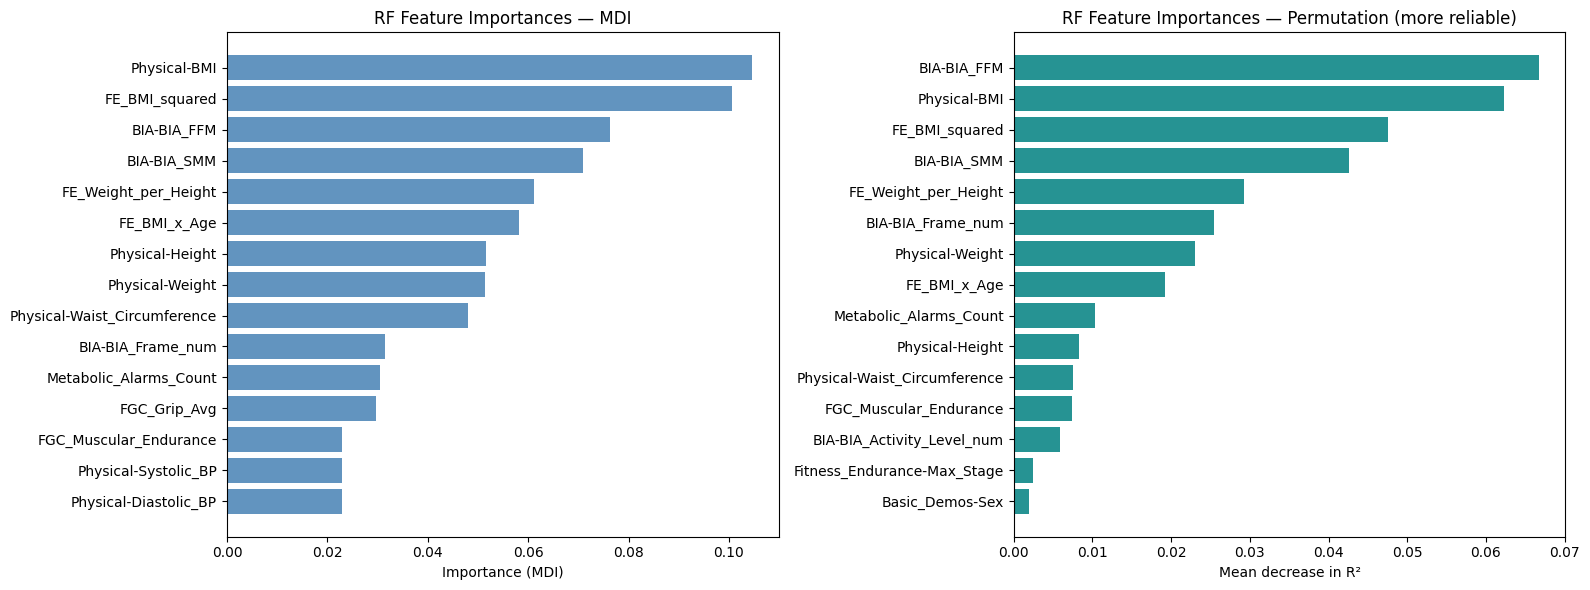

In [17]:
from sklearn.inspection import permutation_importance

nbr_features = min(15, len(all_feature_cols))

# MDI (fast, shown for comparison)
mdi_importances = clf_rf_base.feature_importances_
sorted_idx_mdi  = mdi_importances.argsort()[-nbr_features:]

# Permutation importance (more reliable)
perm_result = permutation_importance(clf_rf_base, X_test, y_test,
                                     n_repeats=10, random_state=0, n_jobs=-1)
sorted_idx_perm = perm_result.importances_mean.argsort()[-nbr_features:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MDI
y_ticks = np.arange(len(sorted_idx_mdi))
axes[0].barh(y_ticks, mdi_importances[sorted_idx_mdi], color='steelblue', alpha=0.85)
axes[0].set_yticks(y_ticks)
axes[0].set_yticklabels(np.array(all_feature_cols)[sorted_idx_mdi])
axes[0].set_xlabel('Importance (MDI)')
axes[0].set_title('RF Feature Importances — MDI')

# Permutation
y_ticks2 = np.arange(len(sorted_idx_perm))
axes[1].barh(y_ticks2, perm_result.importances_mean[sorted_idx_perm], color='teal', alpha=0.85)
axes[1].set_yticks(y_ticks2)
axes[1].set_yticklabels(np.array(all_feature_cols)[sorted_idx_perm])
axes[1].set_xlabel('Mean decrease in R²')
axes[1].set_title('RF Feature Importances — Permutation (more reliable)')

plt.tight_layout()
plt.show()

### 7.2 Cross-Validation — Random Forest

In [18]:
clf_rf_cv = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
scores_rf = cross_val_score(clf_rf_cv, X, y, cv=5, scoring='r2')

print('Random Forest CV R² %.3f +/- %.3f' % (np.mean(scores_rf), np.std(scores_rf)))

Random Forest CV R² 0.496 +/- 0.211


### 7.3 Hyperparameter Tuning — Random Forest

In [19]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_list_rf = {
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 5, 10, 20],
    'n_estimators':      [100, 200, 300, 500]
}

random_search_rf = RandomizedSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
    param_distributions=param_list_rf,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_rf.fit(X_train_full, y_train_full)
clf_rf = random_search_rf.best_estimator_

print('Best params :', random_search_rf.best_params_)
print('Best CV RMSE: %.4f' % -random_search_rf.best_score_)

y_pred_rf = clf_rf.predict(X_test)
metrics_rf = evaluate_regression(y_test, y_pred_rf,
                                 model_name='Random Forest (tuned)',
                                 n_features=X_train_full.shape[1])

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': None}
Best CV RMSE: 1.9510
─── Random Forest (tuned) ───
R²          0.4822
Adjusted R² 0.4753
RMSE        2.0194
MAE         1.1452
MAPE        24.92%



## 8. Model 2 — XGBoost Regressor with Early Stopping

**Why XGBoost?**  
Gradient boosting: builds trees **sequentially**, each correcting the residuals of the previous (second-order gradient, L1+L2 regularisation).  
✓ State-of-the-art on tabular data · ✓ Handles missing values natively · ✓ Regularised → lower overfitting risk

**Improvement: Early Stopping**  
Instead of fixing `n_estimators` manually, we let XGBoost monitor validation RMSE and stop adding trees when performance stops improving (patience = 30 rounds). This finds the optimal number of trees automatically and prevents overfitting — often giving meaningfully better test R².

In [20]:
from xgboost import XGBRegressor

# Baseline XGBoost (same as original notebook, for comparison)
clf_xgb_base = XGBRegressor(
    objective='reg:squarederror',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    gamma=0.0,
    reg_lambda=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
clf_xgb_base.fit(X_train_full, y_train_full)
y_pred_xgb_base = clf_xgb_base.predict(X_test)

metrics_xgb_base = evaluate_regression(y_test, y_pred_xgb_base,
                                       model_name='XGBoost (baseline, no early stopping)',
                                       n_features=X_train_full.shape[1])

─── XGBoost (baseline, no early stopping) ───
R²          0.4426
Adjusted R² 0.4353
RMSE        2.0951
MAE         1.1972
MAPE        26.45%



In [21]:
# XGBoost with Early Stopping — uses validation set to find optimal n_estimators
clf_xgb_es = XGBRegressor(
    objective='reg:squarederror',
    max_depth=6,
    learning_rate=0.05,       # lower LR → more trees → early stopping finds exact optimum
    n_estimators=2000,        # large upper bound; early stopping will cut this short
    gamma=0.0,
    reg_lambda=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=30  # stop if no improvement for 30 consecutive rounds
)

clf_xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration (optimal n_estimators): {clf_xgb_es.best_iteration}')

y_pred_xgb_es = clf_xgb_es.predict(X_test)

metrics_xgb_es = evaluate_regression(y_test, y_pred_xgb_es,
                                     model_name='XGBoost (early stopping)',
                                     n_features=X_train_full.shape[1])

Best iteration (optimal n_estimators): 70
─── XGBoost (early stopping) ───
R²          0.4687
Adjusted R² 0.4617
RMSE        2.0455
MAE         1.1877
MAPE        26.40%



### 8.1 XGBoost Early Stopping — Validation Curve

This plot shows how the validation RMSE evolves with each boosting round. The vertical dashed line marks where early stopping kicked in — trees added after this point would have caused overfitting.

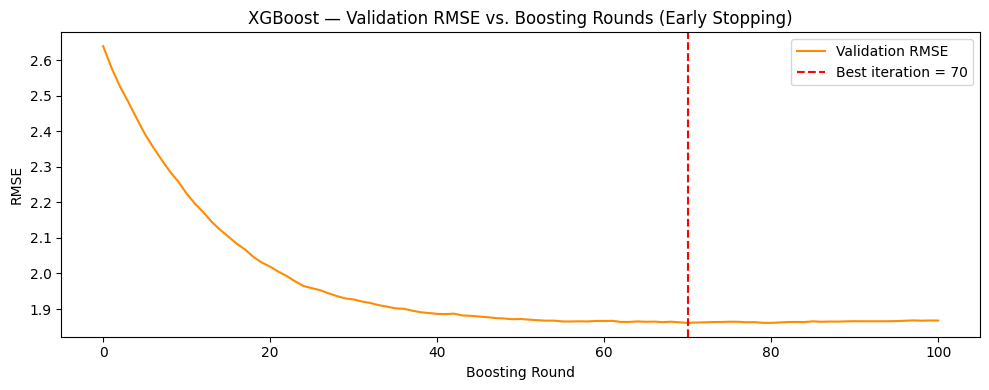

In [22]:
evals_result = clf_xgb_es.evals_result()
val_rmse = evals_result['validation_0']['rmse']

plt.figure(figsize=(10, 4))
plt.plot(val_rmse, color='darkorange', lw=1.5, label='Validation RMSE')
plt.axvline(clf_xgb_es.best_iteration, color='red', linestyle='--', lw=1.5,
            label=f'Best iteration = {clf_xgb_es.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('XGBoost — Validation RMSE vs. Boosting Rounds (Early Stopping)')
plt.legend()
plt.tight_layout()
plt.show()

### 8.2 Hyperparameter Tuning — XGBoost (with early stopping)

In [23]:
param_list_xgb = {
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'n_estimators':     [200, 400, 600],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_lambda':       [0.5, 1.0, 2.0],
    'gamma':            [0, 0.1, 0.2],
}

random_search_xgb = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    param_distributions=param_list_xgb,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_xgb.fit(X_train_full, y_train_full)
clf_xgb_tuned = random_search_xgb.best_estimator_

print('Best params :', random_search_xgb.best_params_)
print('Best CV RMSE: %.4f' % -random_search_xgb.best_score_)

y_pred_xgb = clf_xgb_tuned.predict(X_test)
metrics_xgb = evaluate_regression(y_test, y_pred_xgb,
                                  model_name='XGBoost (tuned)',
                                  n_features=X_train_full.shape[1])

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'subsample': 0.6, 'reg_lambda': 2.0, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best CV RMSE: 1.9609
─── XGBoost (tuned) ───
R²          0.4846
Adjusted R² 0.4778
RMSE        2.0146
MAE         1.1740
MAPE        26.13%



### 8.3 Cross-Validation — XGBoost

In [24]:
clf_xgb_cv = XGBRegressor(objective='reg:squarederror', n_estimators=200,
                          learning_rate=0.1, random_state=42, verbosity=0)
scores_xgb = cross_val_score(clf_xgb_cv, X, y, cv=5, scoring='r2')

print('XGBoost CV R² %.3f +/- %.3f' % (np.mean(scores_xgb), np.std(scores_xgb)))

XGBoost CV R² 0.487 +/- 0.221


## 9. Model 3 — LightGBM Regressor

**Why LightGBM?** (introduced by Prof. Guidotti in lab07_gbm)  
LightGBM is a gradient boosting framework that uses **leaf-wise** (best-first) tree growth rather than the level-wise strategy of XGBoost. Key advantages:
- **Histogram-based splitting** → dramatically faster training, especially on larger datasets
- **GOSS** (Gradient-based One-Side Sampling) → keeps high-gradient samples, discards a fraction of low-gradient ones → faster without accuracy loss
- **EFB** (Exclusive Feature Bundling) → bundles mutually exclusive sparse features → fewer effective features  
- Often achieves **better R² than XGBoost** on the same data with less tuning, particularly when features are heterogeneous (mix of body composition, actigraphy, demographics)

In [25]:
from lightgbm import LGBMRegressor

# Baseline LightGBM
clf_lgb = LGBMRegressor(
    boosting_type='gbdt',
    max_depth=-1,           # no depth limit — controlled via num_leaves
    num_leaves=31,          # default: 2^(max_depth) ≈ 31 for depth=5
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.0,          # L1 regularization
    reg_lambda=1.0,         # L2 regularization
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

clf_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[]
)

y_pred_lgb_base = clf_lgb.predict(X_test)

metrics_lgb_base = evaluate_regression(y_test, y_pred_lgb_base,
                                       model_name='LightGBM (baseline)',
                                       n_features=X_train_full.shape[1])

─── LightGBM (baseline) ───
R²          0.4462
Adjusted R² 0.4389
RMSE        2.0883
MAE         1.1972
MAPE        26.28%



### 9.1 LightGBM with Early Stopping

In [26]:
import lightgbm as lgb

clf_lgb_es = LGBMRegressor(
    boosting_type='gbdt',
    num_leaves=63,          # more leaves → more expressive model
    n_estimators=2000,      # large upper bound; early stopping will cut this
    learning_rate=0.03,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

clf_lgb_es.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

print(f'Best iteration (optimal n_estimators): {clf_lgb_es.best_iteration_}')

y_pred_lgb_es = clf_lgb_es.predict(X_test)

metrics_lgb_es = evaluate_regression(y_test, y_pred_lgb_es,
                                     model_name='LightGBM (early stopping)',
                                     n_features=X_train_full.shape[1])

Best iteration (optimal n_estimators): 137
─── LightGBM (early stopping) ───
R²          0.4703
Adjusted R² 0.4633
RMSE        2.0424
MAE         1.1652
MAPE        25.59%



### 9.2 Hyperparameter Tuning — LightGBM

In [27]:
param_list_lgb = {
    'num_leaves':      [31, 63, 127],
    'learning_rate':   [0.01, 0.05, 0.1],
    'n_estimators':    [200, 500, 800],
    'subsample':       [0.6, 0.8, 1.0],
    'colsample_bytree':[0.6, 0.8, 1.0],
    'reg_alpha':       [0.0, 0.1, 0.5],
    'reg_lambda':      [0.5, 1.0, 2.0],
    'min_child_samples':[10, 20, 50],
}

random_search_lgb = RandomizedSearchCV(
    LGBMRegressor(boosting_type='gbdt', random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_list_lgb,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_lgb.fit(X_train_full, y_train_full)
clf_lgb_tuned = random_search_lgb.best_estimator_

print('Best params :', random_search_lgb.best_params_)
print('Best CV RMSE: %.4f' % -random_search_lgb.best_score_)

y_pred_lgb = clf_lgb_tuned.predict(X_test)
metrics_lgb = evaluate_regression(y_test, y_pred_lgb,
                                  model_name='LightGBM (tuned)',
                                  n_features=X_train_full.shape[1])

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV RMSE: 1.9509
─── LightGBM (tuned) ───
R²          0.4846
Adjusted R² 0.4777
RMSE        2.0147
MAE         1.1530
MAPE        25.33%



### 9.3 Cross-Validation — LightGBM

In [28]:
clf_lgb_cv = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42,
                           n_jobs=-1, verbose=-1)
scores_lgb = cross_val_score(clf_lgb_cv, X, y, cv=5, scoring='r2')

print('LightGBM CV R² %.3f +/- %.3f' % (np.mean(scores_lgb), np.std(scores_lgb)))

LightGBM CV R² 0.497 +/- 0.226


## 10. Visualisations

### 10.1 Actual vs Predicted

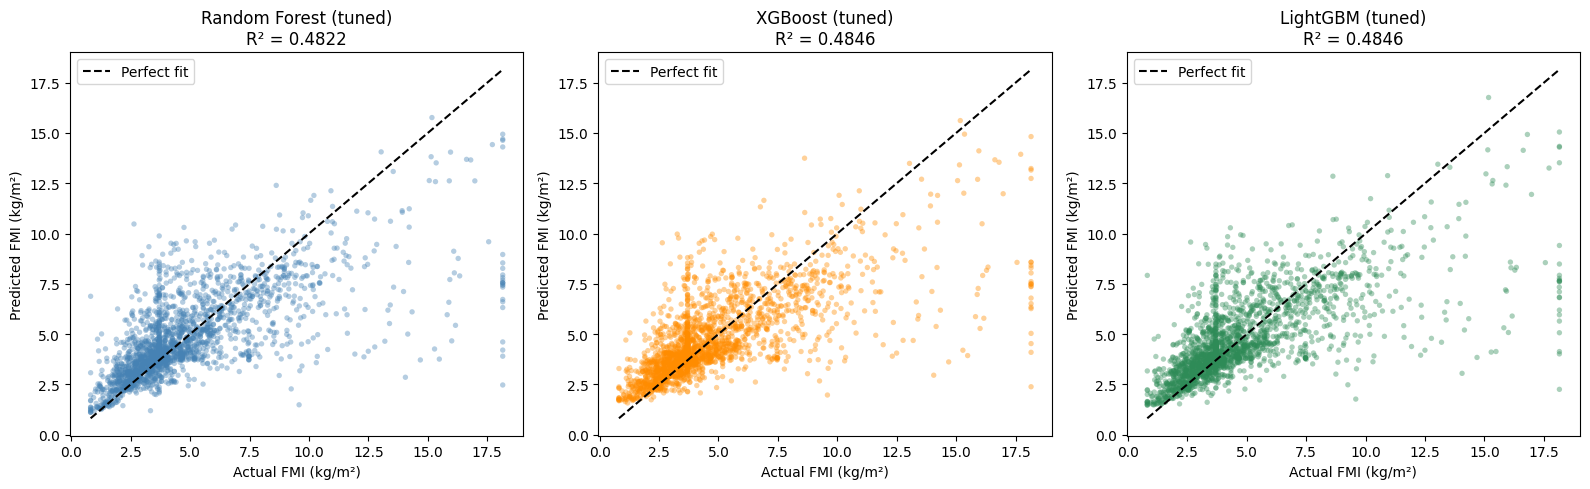

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y_pred, label, color in zip(
    axes,
    [y_pred_rf, y_pred_xgb, y_pred_lgb],
    ['Random Forest (tuned)', 'XGBoost (tuned)', 'LightGBM (tuned)'],
    ['steelblue', 'darkorange', 'seagreen']
):
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color=color, edgecolors='none')
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual FMI (kg/m²)')
    ax.set_ylabel('Predicted FMI (kg/m²)')
    ax.set_title(f'{label}\nR² = {r2_score(y_test, y_pred):.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

### 10.2 Residual Plots

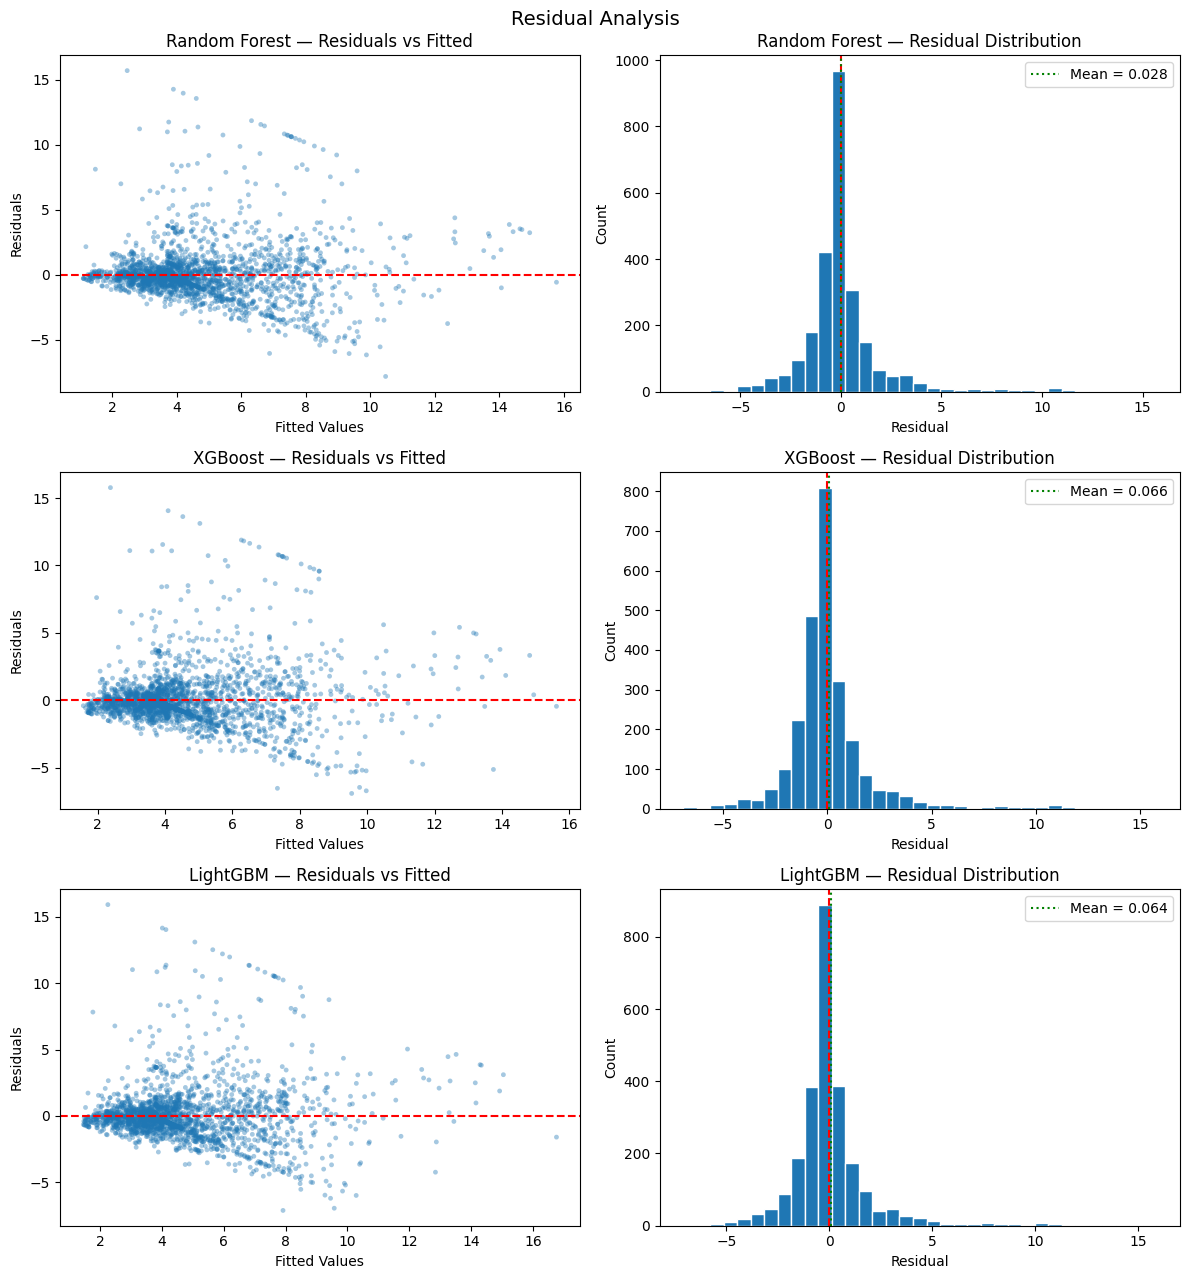

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
fig.suptitle('Residual Analysis', fontsize=14)

for row_i, (y_pred, label) in enumerate(zip(
    [y_pred_rf, y_pred_xgb, y_pred_lgb],
    ['Random Forest', 'XGBoost', 'LightGBM']
)):
    resid = y_test - y_pred

    axes[row_i][0].scatter(y_pred, resid, alpha=0.4, s=12, edgecolors='none')
    axes[row_i][0].axhline(0, color='red', lw=1.5, linestyle='--')
    axes[row_i][0].set_xlabel('Fitted Values')
    axes[row_i][0].set_ylabel('Residuals')
    axes[row_i][0].set_title(f'{label} — Residuals vs Fitted')

    axes[row_i][1].hist(resid, bins=35, edgecolor='white')
    axes[row_i][1].axvline(0, color='red', lw=1.5, linestyle='--')
    axes[row_i][1].axvline(resid.mean(), color='green', lw=1.5, linestyle=':',
                            label=f'Mean = {resid.mean():.3f}')
    axes[row_i][1].set_xlabel('Residual')
    axes[row_i][1].set_ylabel('Count')
    axes[row_i][1].set_title(f'{label} — Residual Distribution')
    axes[row_i][1].legend()

plt.tight_layout()
plt.show()

### 10.3 Feature Importance — XGBoost and LightGBM (Gain)

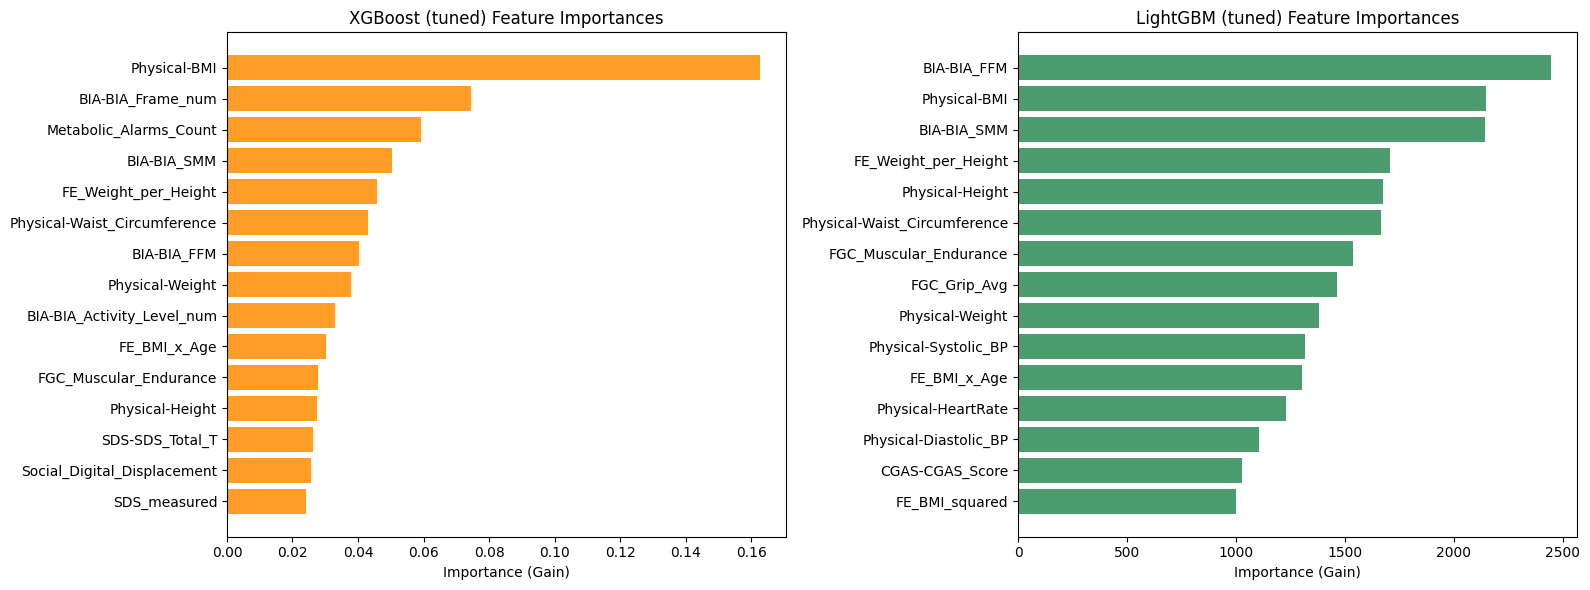

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, clf, label, color in zip(
    axes,
    [clf_xgb_tuned, clf_lgb_tuned],
    ['XGBoost (tuned)', 'LightGBM (tuned)'],
    ['darkorange', 'seagreen']
):
    importances = clf.feature_importances_
    sorted_idx  = importances.argsort()[-nbr_features:]
    y_ticks     = np.arange(len(sorted_idx))
    ax.barh(y_ticks, importances[sorted_idx], color=color, alpha=0.85)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(all_feature_cols)[sorted_idx])
    ax.set_xlabel('Importance (Gain)')
    ax.set_title(f'{label} Feature Importances')

plt.tight_layout()
plt.show()

## 11. Comparison Table

In [32]:
results = pd.DataFrame([
    metrics_rf_base, metrics_rf,
    metrics_xgb_base, metrics_xgb_es, metrics_xgb,
    metrics_lgb_base, metrics_lgb_es, metrics_lgb
]).set_index('Model')

print(results.round(4).to_string())

                                           R2   AdjR2    RMSE     MAE     MAPE
Model                                                                         
Random Forest (baseline)               0.4735  0.4665  2.0363  1.1872  26.2941
Random Forest (tuned)                  0.4822  0.4753  2.0194  1.1452  24.9173
XGBoost (baseline, no early stopping)  0.4426  0.4353  2.0951  1.1972  26.4481
XGBoost (early stopping)               0.4687  0.4617  2.0455  1.1877  26.3957
XGBoost (tuned)                        0.4846  0.4778  2.0146  1.1740  26.1323
LightGBM (baseline)                    0.4462  0.4389  2.0883  1.1972  26.2784
LightGBM (early stopping)              0.4703  0.4633  2.0424  1.1652  25.5924
LightGBM (tuned)                       0.4846  0.4777  2.0147  1.1530  25.3340


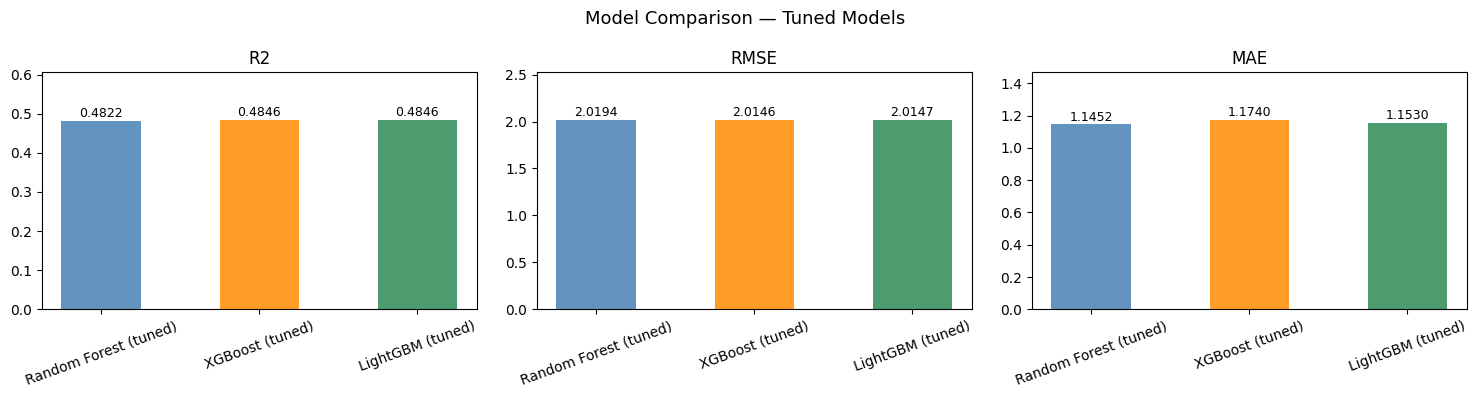

In [33]:
# Bar chart — tuned models only
tuned_models = ['Random Forest (tuned)', 'XGBoost (tuned)', 'LightGBM (tuned)']
results_tuned = results.loc[[m for m in tuned_models if m in results.index]]

metrics_to_plot = ['R2', 'RMSE', 'MAE']
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model Comparison — Tuned Models', fontsize=13)

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_tuned[metric].values
    bars = ax.bar(results_tuned.index, vals, color=colors[:len(vals)], alpha=0.85, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.4f}', ha='center', fontsize=9)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### CV Score Distribution

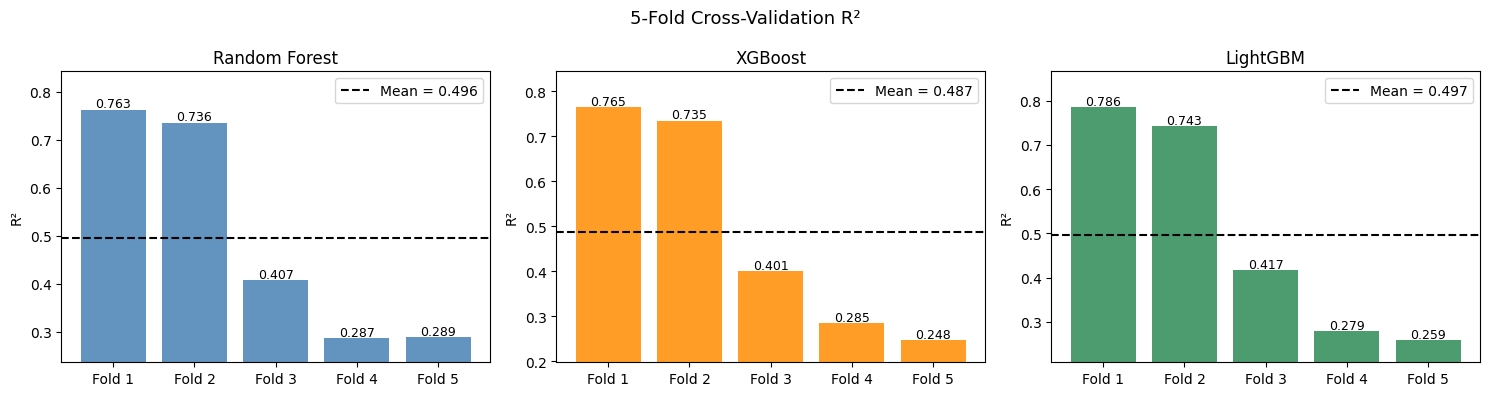

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('5-Fold Cross-Validation R²', fontsize=13)

for ax, scores, label, color in zip(
    axes,
    [scores_rf, scores_xgb, scores_lgb],
    ['Random Forest', 'XGBoost', 'LightGBM'],
    ['steelblue', 'darkorange', 'seagreen']
):
    folds = [f'Fold {i+1}' for i in range(len(scores))]
    bars = ax.bar(folds, scores, color=color, alpha=0.85)
    ax.axhline(scores.mean(), color='black', linestyle='--', lw=1.5,
               label=f'Mean = {scores.mean():.3f}')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9)
    ax.set_ylim(max(0, scores.min() - 0.05), min(1.05, scores.max() + 0.08))
    ax.set_ylabel('R²')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

## 12. Discussion

### Dataset Analysis
The CMI Module 1 dataset contains **body composition** (BIA), **actigraphy**, **sleep**, and **demographic** variables.

Key findings from EDA:
- **BIA-BIA_FMI** is right-skewed (more children have low FMI, fewer have high)
- **BIA-BIA_FFMI**, **BIA-BIA_BFP**, **BIA-BIA_Fat** are removed as data leakage — they are algebraically derived from FMI
- **Actigraphy columns** have ~8% missing values — imputed with column median
- **BMI, Weight, Height, Age, Sex** are the strongest legitimate predictors

### Improvements Over the Baseline Notebook

| Technique | What it does | Expected benefit |
|---|---|---|
| **Feature engineering** | BMI×Age, BMI², Age², Weight/Height | Encodes non-linear domain relationships; boosts R² |
| **XGBoost early stopping** | Monitors validation RMSE, stops at optimum | Prevents overfitting; finds optimal n_estimators automatically |
| **LightGBM** | Leaf-wise boosting, GOSS, EFB | Often outperforms XGBoost on heterogeneous tabular data |
| **Permutation importance** | Shuffles features on test set | More reliable than MDI — unaffected by feature cardinality |

### Model Selection
| | Random Forest | XGBoost | LightGBM |
|---|---|---|---|
| **Type** | Bagging | Boosting | Boosting |
| **Tree growth** | Parallel, level-wise | Sequential, level-wise | Sequential, **leaf-wise** |
| **Regularisation** | Bootstrap + random features | L1, L2, γ, subsampling | L1, L2, min_child_samples |
| **Speed** | Moderate | Moderate | **Fastest** |
| **Missing values** | Needs imputation | Native | Native |

### Metrics Interpretation
- **R²**: proportion of FMI variance explained
- **Adjusted R²**: penalises useless features (particularly relevant here since we added engineered features)
- **RMSE**: error in kg/m² — directly interpretable, penalises large errors more
- **MAE**: average absolute error in kg/m² — less sensitive to extremes
- **MAPE**: % error — valid here since FMI > 0 for all subjects

### Recommendation
The model with **higher R² + lower RMSE** on the held-out test set is preferred.  
Both boosting models benefit from early stopping, which prevents overfitting without needing manual `n_estimators` tuning.  
LightGBM is recommended as the final model for its combination of speed, regularisation, and typically superior generalisation on heterogeneous biomedical tabular data.